## Homework 02-2: due 2024/04/08 23:59 (70%)

### - Tutorial : https://machinelearningmastery.com/pytorch-tutorial-develop-deep-learning-models/

### - After you go through the tutorials, you should be able to work on this assignment.

### - Please answer the following questions and work directly on this jupyter notebook.

### - Make sure the code can be run and show the result and figures properly.

### - Please write down your observation with markdown in this notebook briefly.



#### You will train a regression model in this part. The data is **Concrete Compressive Strength Dataset**, you can find the details of each column at https://archive.ics.uci.edu/ml/datasets/concrete+compressive+strength. In this part, please predict the **strength of concrete**.

In [1]:
# Import necessory modules
%matplotlib inline
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler

In [2]:
# For reproduce the result
torch.manual_seed(1220)
random.seed(1220)
np.random.seed(1220)

In [3]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


### 1. Define the model and dataset (10%)

#### 1.1 Please follow the Step 2 from the tutorial to create a class ***ConcreteDataset*** to load the data you need and also do the ***Min-Max scaling*** to the ***feature and label***. (5%)

In [4]:
class Min_Max_Scaler:
    def __init__(self):
        None

    def fit(self, data):
        self.min = np.min(data, axis=0)  #axis=0 → operate column-wise.Stores values into self.min and self.max so that later we can scale each column accordingly.
        self.max = np.max(data, axis=0)

    def transform(self, data):
        scaling_data = data.copy()      # Creates a copy of the input data to avoid modifying the original data.
        for i in range(data.shape[1]):       #data.shape[1] gives the number of columns in the data.
            scaling_data[:, i] = 2 * ((data[:, i] - self.min[i]) / (self.max[i] - self.min[i])) - 1
        return scaling_data  # This transformation scales each column of the data to the range [-1, 1].
    
    def fit_transform(self, data):  #
        self.fit(data)
        return self.transform(data)

    def y_inverse_transform(self, scaling_y):
        return (scaling_y + 1) * (self.max[-1] - self.min[-1]) / 2 + self.min[-1]

In [5]:
"""
A skeleton of a custom Dataset class is provided below. 
Once loaded, PyTorch provides the DataLoader class to navigate a 
Dataset instance during the training and evaluation of your model.
"""
class ConcreteDataset(Dataset):
   # load the dataset
   def __init__(self, data):
      # store the inputs and outputs
      self.X = torch.tensor(data[:, :-1]).to(torch.float32)
      self.y = torch.tensor(data[:, -1]).to(torch.float32)  #Extracts all columns except the last one (features) using slicing data[:, :-1], then converts it to a PyTorch tensor of type float32.
   
   # number of rows in the dataset 
   def __len__(self):
      return len(self.X)  # Returns the number of samples in the dataset. This is needed by PyTorch to know the dataset size.
   
   # get a row at an index
   def __getitem__(self, idx):
      return self.X[idx], self.y[idx]  # . It allows PyTorch to access individual samples from your dataset when training or evaluating a model. The idx parameter is the index of the sample you want to access.

#### 1.2 By following the tutorial, try to create a class ***MLP(Neural Network)*** with ***three hidden layers*** as your network architecture. Also, for the convenience of implementation, please set the numbers of hidden nodes and the activation functions as input variables to the foward functions.(5%) 

In [ ]:
class MLP_1(nn.Module):  #“I want my MLP class to be based on PyTorch’s built-in nn.Module class.”
    def __init__(self):
        super().__init__()  #Think of super().__init__() like calling your parent’s setup function before you add your own decorations:
        self.net = nn.Sequential(
            nn.Linear(8, 256),
            nn.Tanh(),
            nn.Linear(256, 64),
            nn.Tanh(),
            nn.Linear(64, 8),
            nn.Tanh(),
            nn.Linear(8, 1),
            nn.Tanh(),
        )
        
    def forward(self, X):
        outputs = self.net(X)
        return outputs

In [24]:
class MLP_2(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 64),
            nn.Tanh(),
            nn.Linear(64, 16),
            nn.Tanh(),
            nn.Linear(16, 8),
            nn.Tanh(),
            nn.Linear(8, 1),
        )
        
    def forward(self, X):
        outputs = self.net(X)
        return outputs

In [12]:
"""another version with flexible inputs variables"""  
import torch
import torch.nn as nn

class FlexibleMLP(nn.Module):
    def __init__(self, input_dim=8, output_dim=1, hidden_sizes=[256, 64, 8], 
                 activation_fn=nn.Tanh, output_activation=None):
        super().__init__()

        layers = []
        in_dim = input_dim
        output_activation= output_activation if output_activation is not None else nn.Identity  # Default to identity if no output activation is provided

        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(activation_fn())
            in_dim = h

        layers.append(nn.Linear(in_dim, output_dim))

        if output_activation is not None:
            layers.append(output_activation())  # Add output activation if provided

        self.net = nn.Sequential(*layers)

    def forward(self, X):
        return self.net(X)

    



In [36]:
# Example usage (skip this part if you want to use the FlexibleMLP class directly)

# Use like any PyTorch model
model = FlexibleMLP(
    input_dim=8,
    output_dim=1,
    hidden_sizes=[256, 128, 64],
    activation_fn=nn.Tanh  # or nn.ReLU, nn.LeakyReLU
)

# Use like any PyTorch model
output = model(torch.randn(32, 8))  # batch of 32 samples, each with 8 features  

# save and load Example

# Save model
torch.save(model.state_dict(), 'flexible_mlp.pth')  # Save the model’s weights	Creates a .pth file

# Load model later
model_loaded = FlexibleMLP(input_dim=8, output_dim=1, hidden_sizes=[256, 128, 64], activation_fn=nn.Tanh)   # Rebuild the model structure	Must match original architecture
model_loaded.load_state_dict(torch.load('flexible_mlp.pth'))  # Load saved weights into the new model	Fills in the trained values
model_loaded.eval()  # Switch to inference mode	Use before making predictions  #Puts the model into "evaluation mode" — required before making predictions.

C:\Users\USER\AppData\Local\Temp\ipykernel_11664\1206862356.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_loaded.load_state_dict(torch.load('flexible_mlp.pth'))

FlexibleMLP(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=1, bias=True)
    (7): Identity()
  )
)

if the model is not stored in self, so:

You can't use .parameters() on self to get trainable weights

You can’t save or load the model state easily using torch.save() or model.state_dict()

To fix that, you could build self.net = nn.Sequential(...) inside __init__ after receiving configuration — or pass configuration at construction.

## 🔁 Typical Pattern in Code

```python
nn.Linear(8, 256),   # Linear layer
nn.Tanh(),           # Non-linear activation
```

This **pair** (linear + activation) is what actually gives the network learning power.

---

### ✅ Summary

| Component        | Type                | Purpose                                     |
| ---------------- | ------------------- | ------------------------------------------- |
| `nn.Linear(...)` | Layer               | Applies a linear transformation             |
| `nn.Tanh()`      | Activation Function | Adds non-linearity to the model             |
| Together         | Layer block         | Forms a powerful unit for learning patterns |

## ❌ `nn.Linear(8, 256)` is **not** an activation function.

It is a **fully connected (dense) layer**, also called a **linear transformation layer** in PyTorch.




## 🎯 Step 1: Understand Your Problem Type

| Problem Type                   | Typical Output                                                   |
| ------------------------------ | ---------------------------------------------------------------- |
| **Regression**                 | A single number (e.g., concrete strength) → output size = 1      |
| **Binary Classification**      | Probability of class (0 or 1) → output size = 1 with `Sigmoid()` |
| **Multi-class Classification** | Predict 1 of N classes → output size = N with `Softmax()`        |

---

## 🧠 Step 2: Know Your Input Size

* Count the number of **input features** (columns in your data).
* Example: If your dataset has 8 features (like concrete dataset), then:

  ```python
  nn.Linear(8, ?)
  ```

---

## 🏗️ Step 3: Decide on Architecture

> Rule of thumb: start **simple**, then add complexity if needed.

### ✨ A. Number of Hidden Layers

| Layer Depth       | When to Use                                                   |
| ----------------- | ------------------------------------------------------------- |
| 1 hidden layer    | Usually enough for **simple problems** (shallow MLPs)         |
| 2–3 hidden layers | Good for most **moderate** problems                           |
| 4+ hidden layers  | For **very complex** tasks (image, NLP, etc.) or big datasets |

> ✅ For tabular data (like the concrete dataset), **2 to 3 hidden layers** are usually enough.

---

### ✨ B. Number of Neurons (Width)

No fixed rule, but here’s a good **starting pattern**:

```text
[input_dim] → [4×input_dim] → [2×input_dim] → [input_dim] → [1]
```

### 📘 Example: For 8 input features

```python
nn.Linear(8, 32),  # 4×8
nn.ReLU(),
nn.Linear(32, 16), # 2×8
nn.ReLU(),
nn.Linear(16, 8),  # back to input size
nn.ReLU(),
nn.Linear(8, 1)    # output for regression
```

---

## 🧪 Step 4: Activation Functions

| Function    | When to Use                                     |
| ----------- | ----------------------------------------------- |
| `ReLU()`    | Default for hidden layers — fast and works well |
| `Tanh()`    | Use if your input/output is scaled to \[-1, 1]  |
| `Sigmoid()` | Binary output (probability)                     |
| `Softmax()` | Multi-class classification output               |

For most tasks:

```python
hidden → ReLU  
output → depends on task
```

---

## 🧰 Step 5: Tune and Experiment

Try:

* **Start simple** → test performance
* Use **validation loss** to evaluate
* Increase width/depth only if underfitting
* Use **dropout** if overfitting (too good on training, bad on test)

  ```python
  nn.Dropout(0.3)  # randomly disables 30% of neurons during training
  ```

---

## ✅ General Tips

| Strategy                           | Why                                 |
| ---------------------------------- | ----------------------------------- |
| Use powers of 2 (like 32, 64, 128) | More efficient on modern hardware   |
| Fewer layers for small datasets    | Avoid overfitting                   |
| Normalize your input               | Helps training (Min-Max or Z-score) |
| Use early stopping                 | Prevents overfitting                |
| Visualize training/validation loss | Helps diagnose under/overfitting    |

---

## 🧠 Summary: How to Design MLP

1. **Input size** = number of features
2. **Output size** = based on task (1 for regression)
3. **Hidden layers**: start with 2 or 3
4. **Neurons**: 4×input → 2×input → input
5. **Activations**: ReLU (hidden), Tanh/Sigmoid/None (output)
6. **Tune & validate** with actual performance

---

## ✅ Best Practices

### 1. **Start small**, then increase only if:

* Training loss is still high (underfitting)
* Validation loss is not getting worse (no overfitting)

### 2. Use regularization if going big:

* Add `Dropout` between layers:

  ```python
  nn.Dropout(0.3)
  ```
* Add **weight decay** (L2 penalty) in your optimizer.

### 3. Use early stopping during training

* Stop training when validation loss stops improving.

---

## 🔢 Example: Small vs. Large Design

| Design         | Layers                   | Good For                                            |
| -------------- | ------------------------ | --------------------------------------------------- |
| **Small**      | `8 → 32 → 16 → 8 → 1`    | Small datasets, fast prototyping                    |
| **Medium**     | `8 → 64 → 32 → 16 → 1`   | Medium-sized tabular data                           |
| **Large**      | `8 → 128 → 64 → 32 → 1`  | Big datasets or highly nonlinear patterns           |
| **Very large** | `8 → 256 → 128 → 64 → 1` | Only if you have **a lot of data** (10000+ samples) |

---

## 🤖 Final Tip

You can **use validation curves** to guide your architecture choice:

* Try plotting **model size vs. performance**
* Start small, and increase **only if** you see **consistent improvement**


### 2. Train the model (60%)

#### 2.1 Please load the ***train.csv/ validation.csv*** in ./data, and turn them into dataloader with batch size 64 and determine whether shuffle or not. (5%)

In [13]:
train_data = np.array(pd.read_csv("./data/train.csv"))
test_data = np.array(pd.read_csv("./data/test.csv"))
valid_data = np.array(pd.read_csv("./data/validation.csv"))

scaler = Min_Max_Scaler()

train_data_scaled = scaler.fit_transform(train_data)  # You must only fit the scaler on the training data.
test_data_scaled = scaler.transform(test_data)   # dont fit test and valiadation data prevent data leakage
                                                          # The scaler is fitted on the training data and then used to transform both the test and validation data.
valid_data_scaled = scaler.transform(valid_data)

train_data_loader = DataLoader(ConcreteDataset(train_data_scaled), batch_size=64, shuffle=True)
test_data_loader = DataLoader(ConcreteDataset(test_data_scaled))
valid_data_loader = DataLoader(ConcreteDataset(valid_data_scaled), batch_size=64, shuffle=True)

### Batch size
#### 🧠 Rule of Thumb

> 🔹 **Start with 32 or 64**
> 🔹 If you have more memory and training is smooth, try **doubling** it
> 🔹 If you get out-of-memory or poor performance, **halve it**

---

#### ✅ Summary Table

| Factor                  | Effect on Batch Size      |
| ----------------------- | ------------------------- |
| More memory (GPU)       | Allows **larger** batches |
| Larger model            | Needs **smaller** batches |
| Smaller dataset         | Use **larger** batches    |
| Overfitting risk        | Use **smaller** batches   |
| Smoother training curve | Use **larger** batches    |


### Batchnorm eval and train 
#### ✅ `model.train()` vs `model.eval()`

| Mode            | What it means   | What changes                                                |
| --------------- | --------------- | ----------------------------------------------------------- |
| `model.train()` | Training mode   | Enables **Dropout**, uses **batch stats** in **BatchNorm**  |
| `model.eval()`  | Evaluation mode | Disables **Dropout**, uses **saved stats** in **BatchNorm** |

---

### 🔁 1. `model.train()`: Training Mode

This is the **default** mode. You call this when training your model.

```python
model.train()
```

✔️ What happens:

* **Dropout** layers randomly drop neurons (for regularization)
* **BatchNorm** layers compute **mean/variance from the current mini-batch**

This keeps your model flexible and learning properly.

---

### 🔒 2. `model.eval()`: Evaluation Mode

You call this before:

* **Validation**
* **Testing**
* **Saving predictions**

```python
model.eval()
```

✔️ What changes:

* **Dropout** is turned OFF → no random behavior
* **BatchNorm** uses **saved (running average)** of mean/variance from training

This makes your results **stable and reproducible** — exactly what you want when measuring accuracy or making predictions.

### Data loader parameters  

| Parameter         | Use When…                                                |
| ----------------- | -------------------------------------------------------- |
| `shuffle=True`    | Training data, to randomize batches                      |
| `shuffle=False`   | Validation or test data                                  |
| `drop_last=True`  | You want all batches the same size (e.g., for BatchNorm) |
| `num_workers=0`   | Simpler code/debugging; use on Windows                   |
| `num_workers=2+`  | You want faster data loading (on Linux/macOS)            |
| `pin_memory=True` | You are training on GPU and want faster data transfer    |




#### 2.2 Create two MLP model from the table below and ***print the model*** (10%):
| | Hidden Layer 1| Hidden Layer 2| Hidden Layer 3| Activation in each hidden nodes | Activation for output |
|:---:|:---:|:---:|:---:|:---:|:---:|
|***Model1***| 256 | 64 | 8 | Tanh | Tanh |
|***Model1***| 64 | 16 | 8 | Tanh | Identity |

In [ ]:
# defult model
model_1 = MLP_1().to(device)
model_2 = MLP_2().to(device)
print("Model 1:\n", model_1, "\n\nModel 1:\n", model_2)

NameError: name 'MLP_1' is not defined

In [40]:
# Flexible model
model_1 = FlexibleMLP(
    input_dim=8,
    output_dim=1,
    hidden_sizes=[256, 64, 8],
    activation_fn=nn.Tanh,
    output_activation=nn.Tanh
).to(device)

model_2 = FlexibleMLP(
    input_dim=8,
    output_dim=1,
    hidden_sizes=[64, 16, 8],
    activation_fn=nn.Tanh,
    output_activation=nn.Identity  # Identity, i.e., no activation
).to(device)

print("Model 1:\n", model_1, "\n\nModel 1:\n", model_2)



Model 1:
 FlexibleMLP(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=8, bias=True)
    (5): Tanh()
    (6): Linear(in_features=8, out_features=1, bias=True)
    (7): Tanh()
  )
) 

Model 1:
 FlexibleMLP(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=16, bias=True)
    (3): Tanh()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): Tanh()
    (6): Linear(in_features=8, out_features=1, bias=True)
    (7): Identity()
  )
)


### to device
#### 🧠 Why move only the model to GPU?

Moving the model to GPU allows its parameters to live in GPU memory.
But the **data comes in one batch at a time**, so we:

* Move the **model once** with `.to(device)`
* Move the **data batch-by-batch** during training/inference

This saves **GPU memory** and **avoids crashing** if the dataset is large.

#### 2.3 Train the above two models with the same hyperpameters below and do the validation in every epoch. Choose the appropriate type of loss function according to the task. (25%)
##### (Note. You should record the training/validation loss every epoch)


| | Learning rate | epochs | optimizer | momentum |
|:---:|:---:|:---:|:---:|:---:|
|***Hyperparameter***| 0.01 | 300 | SGD | 0.9 |

## Define loss funct + optimizer

In [41]:
loss_fn = nn.MSELoss()
optimizer_1 = torch.optim.SGD(model_1.parameters(), lr=0.01, momentum=0.9)
optimizer_2 = torch.optim.SGD(model_2.parameters(), lr=0.01, momentum=0.9)

## Define train funct and validation funct

In [43]:
def train(dataloader, model, loss_fn, optimizer):
    epoch_loss = 0.
    model.train()
    for batch, (X, y) in enumerate(dataloader):    # batch is batch index, (X, y) is the minibatch data 
        X, y = X.to(device), y.to(device)   #  if your batch_size = 64 and your dataset has 320 samples:
        # You’ll run 5 iterations (320 ÷ 64 = 5) Each time, X will be a tensor of shape [64, num_features], and y will be [64]

        pred = model(X)
        loss = loss_fn(pred, y.unsqueeze(1))  # MSE loss function outputs a value that measures the average squared difference between the predicted and actual values.

        optimizer.zero_grad()  # Clears old gradients from the previous step (PyTorch accumulates them by default).
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()  # Converts the scalar tensor (like tensor(0.054)) Into a python float: 0.054 which is useful for logging or printing.
        
    epoch_loss /= len(dataloader)
    return epoch_loss

def valid(dataloader, model, loss_fn):
    epoch_loss = 0.
    model.eval()     # Switch to evaluation mode. This is important because it changes the behavior of certain layers like dropout and batch normalization.
    with torch.no_grad():      # Disables gradient calculation, which reduces memory consumption for computations that would otherwise require gradients.
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)   # to set input and output tensors to the same device as the model (CPU or GPU).
            # This ensures that the model can process the data without device mismatch errors.

            pred = model(X)  
            loss = loss_fn(pred, y.unsqueeze(1))
            epoch_loss += loss.item()

        epoch_loss /= len(dataloader)
    return epoch_loss

## Run train

⚠️ 小提醒：效能問題
在每次用 np.append() 時，它都會建立一個新的陣列並複製原始資料 ➜ 對於大量迴圈（如 300 次 epoch）來說效率不高。

✅ 更好的寫法是先用 Python list 收集，再轉成 NumPy 陣列：
train_loss_1, valid_loss_1, train_loss_2, valid_loss_2 = [], [], [], []

for i in loop:
    train_loss_1.append(train(train_data_loader, model_1, loss_fn, optimizer_1))
    valid_loss_1.append(valid(valid_data_loader, model_1, loss_fn))
    train_loss_2.append(train(train_data_loader, model_2, loss_fn, optimizer_2))
    valid_loss_2.append(valid(valid_data_loader, model_2, loss_fn))

    loop.set_description(f"Epoch {i+1}/{epochs}")
    loop.set_postfix(
        model_1_train_loss=f"{train_loss_1[-1]:.6f}",
        model_1_valid_loss=f"{valid_loss_1[-1]:.6f}",
        model_2_train_loss=f"{train_loss_2[-1]:.6f}",
        model_2_valid_loss=f"{valid_loss_2[-1]:.6f}"
    )


import numpy as np

train_loss_1 = np.array(train_loss_1)
valid_loss_1 = np.array(valid_loss_1)
train_loss_2 = np.array(train_loss_2)
valid_loss_2 = np.array(valid_loss_2)

In [28]:
epochs = 300
loop = tqdm(range(epochs))
train_loss_1, valid_loss_1, train_loss_2, valid_loss_2 = np.array([]), np.array([]), np.array([]), np.array([])
for i in loop:
    train_loss_1 = np.append(train_loss_1, train(train_data_loader, model_1, loss_fn, optimizer_1))
    valid_loss_1 = np.append(valid_loss_1, valid(valid_data_loader, model_1, loss_fn))
    train_loss_2 = np.append(train_loss_2, train(train_data_loader, model_2, loss_fn, optimizer_2))
    valid_loss_2 = np.append(valid_loss_2, valid(valid_data_loader, model_2, loss_fn))
    loop.set_description(f"Epoch {i+1}/{epochs}")
    loop.set_postfix(model_1_train_loss=f"{train_loss_1[-1]:.6f}", model_1_valid_loss=f"{valid_loss_1[-1]:.6f}", model_2_train_loss=f"{train_loss_2[-1]:.6f}", model_2_valid_loss=f"{valid_loss_2[-1]:.6f}")

Epoch 300/300: 100%|██████████| 300/300 [00:14<00:00, 20.64it/s, model_1_train_loss=0.026035, model_1_valid_loss=0.066412, model_2_train_loss=0.028963, model_2_valid_loss=0.079764]


In [32]:
epochs = 300
train_loss_1, valid_loss_1, train_loss_2, valid_loss_2 = np.array([]), np.array([]), np.array([]), np.array([])

for i in range(epochs):
    tl1 = train(train_data_loader, model_1, loss_fn, optimizer_1)
    vl1 = valid(valid_data_loader, model_1, loss_fn)
    tl2 = train(train_data_loader, model_2, loss_fn, optimizer_2)
    vl2 = valid(valid_data_loader, model_2, loss_fn)

    train_loss_1 = np.append(train_loss_1, tl1)
    valid_loss_1 = np.append(valid_loss_1, vl1)
    train_loss_2 = np.append(train_loss_2, tl2)
    valid_loss_2 = np.append(valid_loss_2, vl2)

    print(f"Epoch {i+1:03}/{epochs}: "
          f"Model 1 - Train Loss: {tl1:.6f}, Valid Loss: {vl1:.6f} | "
          f"Model 2 - Train Loss: {tl2:.6f}, Valid Loss: {vl2:.6f}")


Epoch 001/300: Model 1 - Train Loss: 0.170300, Valid Loss: 0.144343 | Model 2 - Train Loss: 0.207187, Valid Loss: 0.185239
Epoch 002/300: Model 1 - Train Loss: 0.131582, Valid Loss: 0.112934 | Model 2 - Train Loss: 0.156538, Valid Loss: 0.123358
Epoch 003/300: Model 1 - Train Loss: 0.103417, Valid Loss: 0.100188 | Model 2 - Train Loss: 0.130060, Valid Loss: 0.132257
Epoch 004/300: Model 1 - Train Loss: 0.087171, Valid Loss: 0.121375 | Model 2 - Train Loss: 0.109328, Valid Loss: 0.113849
Epoch 005/300: Model 1 - Train Loss: 0.077451, Valid Loss: 0.116026 | Model 2 - Train Loss: 0.096307, Valid Loss: 0.124739
Epoch 006/300: Model 1 - Train Loss: 0.074844, Valid Loss: 0.110060 | Model 2 - Train Loss: 0.088606, Valid Loss: 0.111563
Epoch 007/300: Model 1 - Train Loss: 0.072706, Valid Loss: 0.109292 | Model 2 - Train Loss: 0.082383, Valid Loss: 0.115804
Epoch 008/300: Model 1 - Train Loss: 0.072002, Valid Loss: 0.114896 | Model 2 - Train Loss: 0.078365, Valid Loss: 0.111596
Epoch 009/300: M

### 📊 Summary Table

| Step                 | `train()` | `valid()` |
| -------------------- | --------- | --------- |
| Forward pass         | ✅         | ✅         |
| Compute loss         | ✅         | ✅         |
| `loss.backward()`    | ✅         | ❌         |
| `optimizer.step()`   | ✅         | ❌         |
| `model.train()` mode | ✅         | ❌         |
| `model.eval()` mode  | ❌         | ✅         |
| `torch.no_grad()`    | ❌         | ✅         |

---
### Evaluate loss 
Great follow-up! Let's break it down:

---

#### 🔢 Why does MSE Loss ≈ 0.03 → Mean Error ≈ 0.16?

You're using **Mean Squared Error (MSE)** as your loss function. Here's what that means mathematically:

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

* It measures the **average of the squares** of the prediction errors.
* But what we really care about is: **how far off (on average)** are our predictions?

  * That’s actually the **Root Mean Squared Error (RMSE)**:

$$
\text{RMSE} = \sqrt{\text{MSE}}
$$

---

#### 🧠 Example:

If your model gives an MSE of **0.026**, then:

$$
\text{RMSE} = \sqrt{0.026} \approx 0.161
$$

That means:
➡️ **On average, each prediction is about 0.16 units away from the true value**.

---

#### 📌 Why is that “pretty decent”?

If your target variable (like concrete strength) has been **scaled to range from -1 to 1**, then:

* The **total spread** of the data is only 2 units (from -1 to 1).
* A prediction error of 0.16 to 0.28 is **within 8–14% of that range**.
* That suggests your model is making **relatively accurate predictions**, especially for real-world regression tasks.

---

#### ✅ Bottom Line:

You use √MSE to estimate **average error**, and compare that to your **target scale**.
That’s how we interpret “is the loss large or small.”




#### 2.4 Please include the plot that shows how the training/validation loss vary with the training epoch. Show the plots using the above two models and write down the observation. (5%)

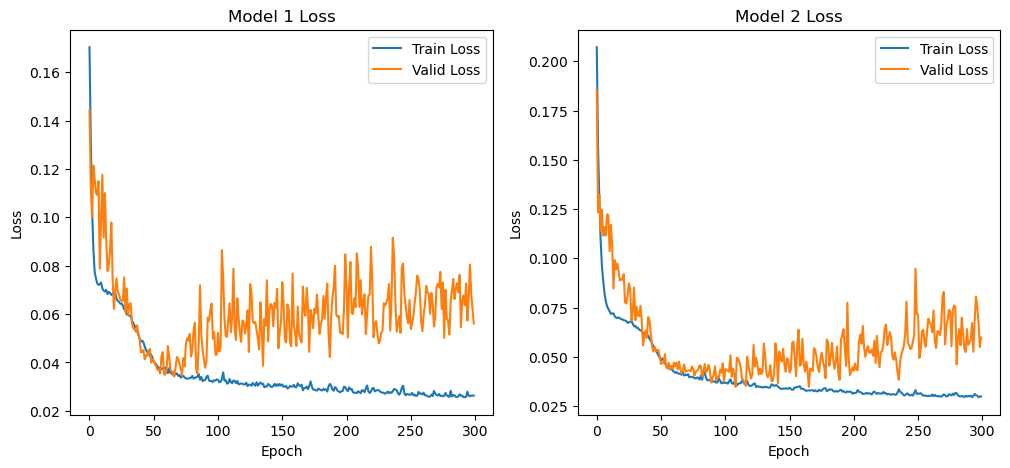

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].set_title("Model 1 Loss")
ax[0].plot(train_loss_1, label="Train Loss")
ax[0].plot(valid_loss_1, label="Valid Loss")
ax[1].set_title("Model 2 Loss")
ax[1].plot(train_loss_2, label="Train Loss")
ax[1].plot(valid_loss_2, label="Valid Loss")
for i in range(2):
    ax[i].set_xlabel("Epoch")
    ax[i].set_ylabel("Loss")
    ax[i].legend()
plt.show()

#### 2.5 From the observation of the previous question, please determine an appropriate epoch and retrain the two models to avoid overfitting. Also, draw the loss plot of two models and save the last model as ***model1.pth*** and ***model2.pth***. (10%)
##### (Note. You should reload the models and the optimizer, otherwise, you will resume from the previous stop.)

Model 2 Epoch 80/300: 100%|██████████| 80/80 [00:02<00:00, 27.79it/s, model_2_train_loss=0.038613, model_2_valid_loss=0.037052]


Saved PyTorch Model State to "model1.pth", and "model2.pth"


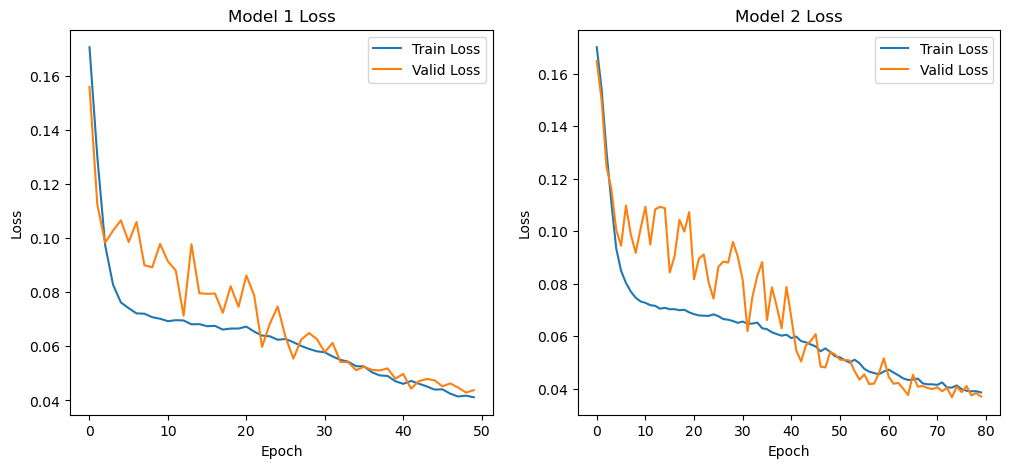

In [44]:
epochs1 = 50
epochs2 = 80
loop1 = tqdm(range(epochs1))
loop2 = tqdm(range(epochs2))
"""
# Flexible model
model_1 = FlexibleMLP(
    input_dim=8,
    output_dim=1,
    hidden_sizes=[256, 64, 8],
    activation_fn=nn.Tanh,
    output_activation=nn.Tanh
).to(device)

model_2 = FlexibleMLP(
    input_dim=8,
    output_dim=1,
    hidden_sizes=[64, 16, 8],
    activation_fn=nn.Tanh,
    output_activation=nn.Identity  # Identity, i.e., no activation
).to(device)
"""
loss_fn = nn.MSELoss()
optimizer_1 = torch.optim.SGD(model_1.parameters(), lr=0.01, momentum=0.9)
optimizer_2 = torch.optim.SGD(model_2.parameters(), lr=0.01, momentum=0.9)
train_loss_1, valid_loss_1, train_loss_2, valid_loss_2 = np.array([]), np.array([]), np.array([]), np.array([])
""""""
for i in loop1:
    train_loss_1 = np.append(train_loss_1, train(train_data_loader, model_1, loss_fn, optimizer_1))
    valid_loss_1 = np.append(valid_loss_1, valid(valid_data_loader, model_1, loss_fn))
    loop1.set_description(f"Model 1 Epoch {i+1}/{epochs}")
    loop1.set_postfix(model_1_train_loss=f"{train_loss_1[-1]:.6f}", model_1_valid_loss=f"{valid_loss_1[-1]:.6f}")

for i in loop2:
    train_loss_2 = np.append(train_loss_2, train(train_data_loader, model_2, loss_fn, optimizer_2))
    valid_loss_2 = np.append(valid_loss_2, valid(valid_data_loader, model_2, loss_fn))
    loop2.set_description(f"Model 2 Epoch {i+1}/{epochs}")
    loop2.set_postfix(model_2_train_loss=f"{train_loss_2[-1]:.6f}", model_2_valid_loss=f"{valid_loss_2[-1]:.6f}")

torch.save(model_1.state_dict(), "model1.pth")  # Save the model’s weights	Creates a .pth file
torch.save(model_2.state_dict(), "model2.pth")  # Save the model’s weights	Creates a .pth file
print("Saved PyTorch Model State to \"model1.pth\", and \"model2.pth\"")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].set_title("Model 1 Loss")
ax[0].plot(train_loss_1, label="Train Loss")
ax[0].plot(valid_loss_1, label="Valid Loss")
ax[1].set_title("Model 2 Loss")
ax[1].plot(train_loss_2, label="Train Loss")
ax[1].plot(valid_loss_2, label="Valid Loss")
for i in range(2):
    ax[i].set_xlabel("Epoch")
    ax[i].set_ylabel("Loss")
    ax[i].legend()
plt.show()

#### 2.6 Please load the checkpoints saved from previous question and calculate the mean squared error on test dataset for two models respectively. Also, make a dataframe with target and prediction like below and save it as ***regression.csv*** (5%)
|Target|Model1|Model2|
|:---:|:---:|:---:|
|24.05|26.35|27.04|
|21.67|32.78|21.95|

## Define test function

In [45]:
def test(dataloader, model, loss_fn):
    model.eval()
    pred_all = np.array([])
    test_loss = 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y.unsqueeze(1)).item()  
            pred_all = np.append(pred_all, pred.cpu().numpy())   #np.append(arr, values, axis=None)
    test_loss /= len(dataloader)
    return test_loss, pred_all

In [46]:
model_1.load_state_dict(torch.load("model1.pth"))
model_2.load_state_dict(torch.load("model2.pth"))
model_1.eval()
model_2.eval()

test1_loss, pred1 = test(test_data_loader, model_1, loss_fn)
test2_loss, pred2 = test(test_data_loader, model_2, loss_fn)
print(f"Test 1 average loss: {test1_loss:>8f}\nTest 2 average loss: {test2_loss:>8f}")

pred1 = scaler.y_inverse_transform(pred1)
pred2 = scaler.y_inverse_transform(pred2)

regression_result = pd.DataFrame({"Target":test_data[:, -1], "Model1": pred1, "Model2": pred2})
regression_result

Test 1 average loss: 0.035098
Test 2 average loss: 0.032801


C:\Users\USER\AppData\Local\Temp\ipykernel_11664\1773479504.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_1.load_state_dict(torch.load("model1.pth"))
C:\Users\US

,Target,Model1,Model2
0,26.06,36.168877,38.256497
1,10.35,15.445467,12.363482
2,74.99,55.264390,51.160890
3,59.00,52.727801,49.278089
4,52.12,42.568770,41.179509
...,...,...,...
98,33.40,35.044801,34.071871
99,39.27,35.257122,35.049937
100,18.13,20.376384,19.573824
101,33.01,23.855568,22.203571


In [47]:
regression_result.to_csv("regression.csv", index=False)
print("Saved regression result to \"regression.csv\"")

Saved regression result to "regression.csv"
